# Federation after feature selection — the four LASSO features

LASSO with ADMM consensus, fit on the extended panel (Panel B) excluding
SDY1737, keeps four features and zeros the rest:

| Feature | Coefficient |
|---|---|
| weight_kg | +0.97 |
| GAD65 | −0.12 |
| received_active_treatment | +0.08 |
| Sex | +0.06 |

GAD65 is negative: higher autoantibody, lower residual C-peptide. weight_kg is
the largest term.

This notebook refits three methods — MLR (Ridge), LASSO, and Random Forest — on
those four features only, and shows the prediction as SDY524 is added to
SDY569. The target is log(C-peptide AUC).


## 1. Setup

In [1]:
from __future__ import annotations
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

REPO = Path.cwd()
if (REPO / "src").exists():
    sys.path.insert(0, str(REPO / "src"))
elif (REPO.parent / "src").exists():
    REPO = REPO.parent
    sys.path.insert(0, str(REPO / "src"))
os.chdir(REPO)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold

import oadr_data as od

RNG_SEED = 42
N_TREES = 200
np.random.seed(RNG_SEED)
(REPO / "results").mkdir(exist_ok=True)
(REPO / "figures").mkdir(exist_ok=True)

SELECTED = ["weight_kg", "GAD65", "received_active_treatment", "Sex"]
print("Repo root:", REPO)
print("Selected features:", SELECTED)


Repo root: /Users/adeslatt/Scitechcon Dropbox/Anne DeslattesMays/projects/oadr-autoantibody
Selected features: ['weight_kg', 'GAD65', 'received_active_treatment', 'Sex']


## 2. Load the four features for SDY569 and SDY524

Each study is loaded on its own. The extended panel is built per study, then
the four selected columns are kept.


In [2]:
def load_selected(study):
    b = od.load_panel_b(study)
    for col in ("bmi", "height_cm", "weight_kg"):
        b[col] = b[col].fillna(b[col].median())
    bad = b["height_cm"] <= 0
    b.loc[bad, "height_cm"] = np.sqrt(b.loc[bad, "weight_kg"] / b.loc[bad, "bmi"]) * 100
    X, y, _ = od.panel_b_design_matrix(b)
    return X.reindex(columns=SELECTED).values.astype(float), y.values.astype(float)

data = {s: load_selected(s) for s in ("SDY569", "SDY524")}
for s in data:
    print(f"{s}: N={len(data[s][1])}, features={len(SELECTED)}")


SDY569: N=10, features=4
SDY524: N=72, features=4


## 3. Federated refit, SDY569 then SDY569 + SDY524

Each study scales its features (MinMaxScaler) and fits the model on its own
rows. For MLR and LASSO the per-study coefficients are combined by
sample-size-weighted mean; for Random Forest each study keeps its forest and
predictions are averaged across forests. Five-fold cross-validation; each study
predicts its own held-out rows. MSE and R² are computed across all held-out
predictions.


In [3]:
def fed_cv(studies, model_fn, kind):
    folds = {s: list(KFold(min(5, max(2, len(data[s][1]) // 2)),
                           shuffle=True, random_state=RNG_SEED).split(data[s][0]))
             for s in studies}
    nf = min(len(folds[s]) for s in studies)
    oof = {s: np.full(len(data[s][1]), np.nan) for s in studies}
    for k in range(nf):
        models, scalers = {}, {}
        for s in studies:
            X, y = data[s]; tr, te = folds[s][k]
            sc = MinMaxScaler().fit(X[tr]); scalers[s] = sc
            m = model_fn().fit(sc.transform(X[tr]), y[tr]); models[s] = m
        if kind == "forest":
            for s in studies:
                X, y = data[s]; tr, te = folds[s][k]
                preds = [models[t].predict(scalers[t].transform(X[te])) for t in studies]
                oof[s][te] = np.mean(preds, axis=0)
        else:
            coefs = np.stack([models[s].coef_ for s in studies])
            ints = np.array([models[s].intercept_ for s in studies])
            sizes = np.array([len(folds[s][k][0]) for s in studies])
            ac = np.average(coefs, axis=0, weights=sizes)
            ai = np.average(ints, weights=sizes)
            for s in studies:
                X, y = data[s]; tr, te = folds[s][k]
                oof[s][te] = scalers[s].transform(X[te]) @ ac + ai
    RSS = SY = SY2 = N = 0
    for s in studies:
        y = data[s][1]; p = oof[s]; m = ~np.isnan(p)
        RSS += np.sum((y[m] - p[m]) ** 2); SY += y[m].sum(); SY2 += (y[m] ** 2).sum(); N += m.sum()
    g = SY / N; TSS = SY2 - N * g * g
    return RSS / N, (1 - RSS / TSS if TSS > 0 else float("nan")), oof

METHODS = [
    ("MLR (Ridge)", lambda: Ridge(alpha=1.0), "linear"),
    ("LASSO", lambda: Lasso(alpha=0.008, max_iter=50000), "linear"),
    ("Random Forest", lambda: RandomForestRegressor(n_estimators=N_TREES, min_samples_leaf=2,
                                                     n_jobs=1, random_state=RNG_SEED), "forest"),
]

rows = []
oof_store = {}
for name, fn, kind in METHODS:
    mse1, r2_1, _ = fed_cv(["SDY569"], fn, kind)
    mse2, r2_2, oof2 = fed_cv(["SDY569", "SDY524"], fn, kind)
    oof_store[name] = oof2
    rows.append({"method": name,
                 "SDY569_MSE": mse1, "SDY569_R2": r2_1,
                 "SDY569+SDY524_MSE": mse2, "SDY569+SDY524_R2": r2_2,
                 "direction": "improves" if r2_2 > r2_1 else "worsens"})

results = pd.DataFrame(rows)
print(results.to_string(index=False))
results.to_csv("results/postlasso_sdy569_sdy524.csv", index=False)


       method  SDY569_MSE  SDY569_R2  SDY569+SDY524_MSE  SDY569+SDY524_R2 direction
  MLR (Ridge)    0.488609  -0.167627           0.111404          0.355547  improves
        LASSO    0.403395   0.036007           0.108085          0.374747  improves
Random Forest    0.297466   0.289145           0.134817          0.220108   worsens


## 4. Scatter — SDY569 alone vs SDY569 + SDY524

For each method, the held-out predictions against the observed values. Left:
SDY569 fit on itself. Right: SDY569 + SDY524 federated. Points on the diagonal
are exact predictions.


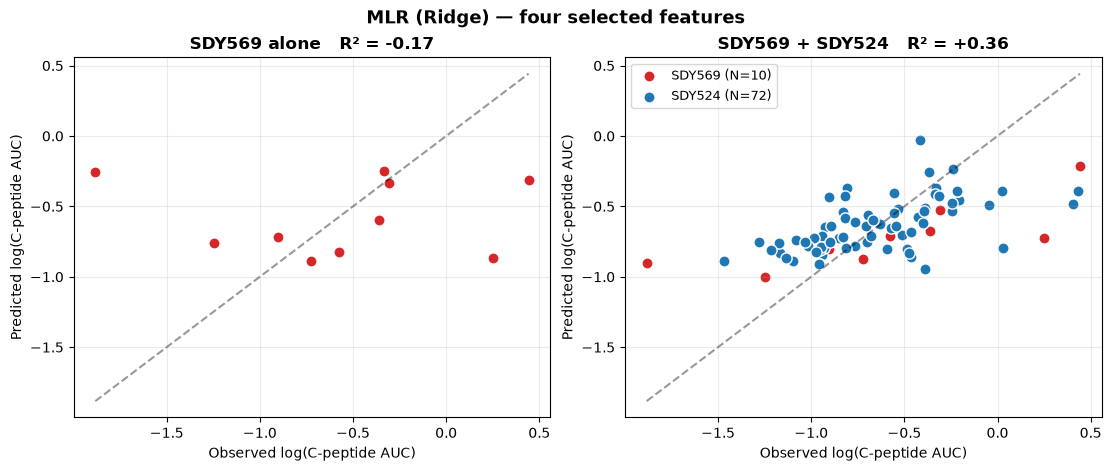

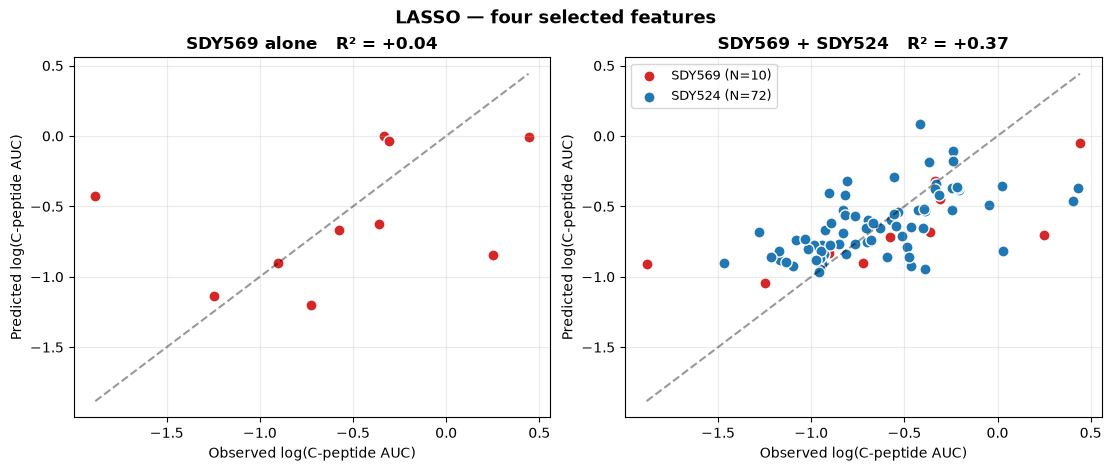

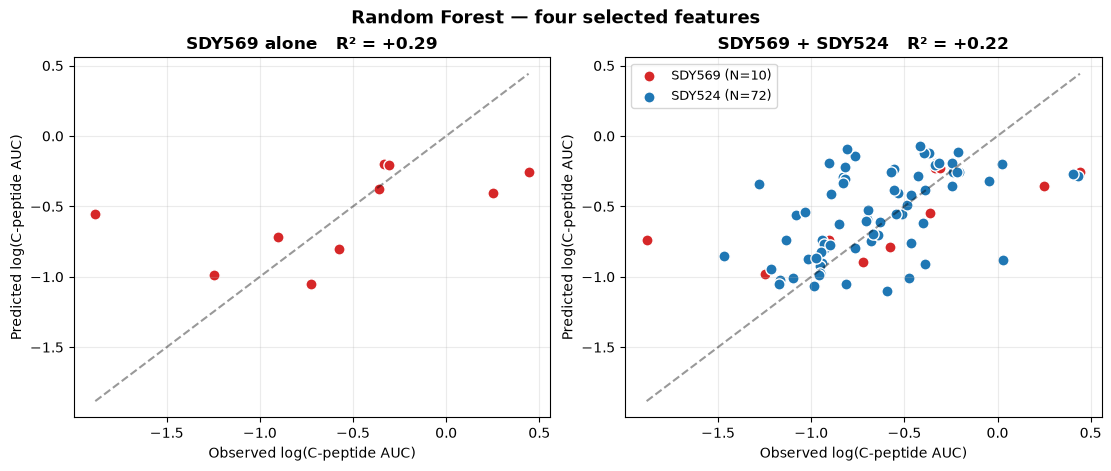

In [4]:
study_colors = {"SDY569": "#d62728", "SDY524": "#1f77b4"}

def scatter_method(name, fn, kind):
    _, r2_solo, oof_solo = fed_cv(["SDY569"], fn, kind)
    _, r2_fed, oof_fed = fed_cv(["SDY569", "SDY524"], fn, kind)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), constrained_layout=True)
    # left: SDY569 alone
    y = data["SDY569"][1]; p = oof_solo["SDY569"]; m = ~np.isnan(p)
    axes[0].scatter(y[m], p[m], c=study_colors["SDY569"], s=65, edgecolor="white")
    lo, hi = min(y[m].min(), p[m].min()), max(y[m].max(), p[m].max())
    axes[0].plot([lo, hi], [lo, hi], "k--", alpha=0.4)
    axes[0].set_title(f"SDY569 alone   R² = {r2_solo:+.2f}", fontweight="bold")
    # right: federated
    for s in ("SDY569", "SDY524"):
        y = data[s][1]; p = oof_fed[s]; m = ~np.isnan(p)
        axes[1].scatter(y[m], p[m], c=study_colors[s], s=65, edgecolor="white", label=f"{s} (N={m.sum()})")
    ally = np.concatenate([data[s][1] for s in ("SDY569", "SDY524")])
    allp = np.concatenate([oof_fed[s] for s in ("SDY569", "SDY524")])
    mm = ~np.isnan(allp)
    lo, hi = min(ally[mm].min(), allp[mm].min()), max(ally[mm].max(), allp[mm].max())
    axes[1].plot([lo, hi], [lo, hi], "k--", alpha=0.4)
    axes[1].set_title(f"SDY569 + SDY524   R² = {r2_fed:+.2f}", fontweight="bold")
    axes[1].legend(fontsize=9)
    for ax in axes:
        ax.set_xlabel("Observed log(C-peptide AUC)")
        ax.set_ylabel("Predicted log(C-peptide AUC)")
        ax.grid(alpha=0.25)
    fig.suptitle(f"{name} — four selected features", fontsize=13, fontweight="bold")
    tag = name.split()[0].lower().replace("(", "").replace(")", "")
    fig.savefig(f"figures/postlasso_scatter_{tag}.pdf", dpi=300)
    fig.savefig(f"figures/postlasso_scatter_{tag}.png", dpi=220)
    plt.show()

for name, fn, kind in METHODS:
    scatter_method(name, fn, kind)


## 5. Panel A reference — the autoantibody panel alone

For contrast: the same federation on Panel A (the five autoantibodies plus age
and sex), all four studies. These features do not predict C-peptide AUC; the
extended panel and the four selected features above are what carry the signal.


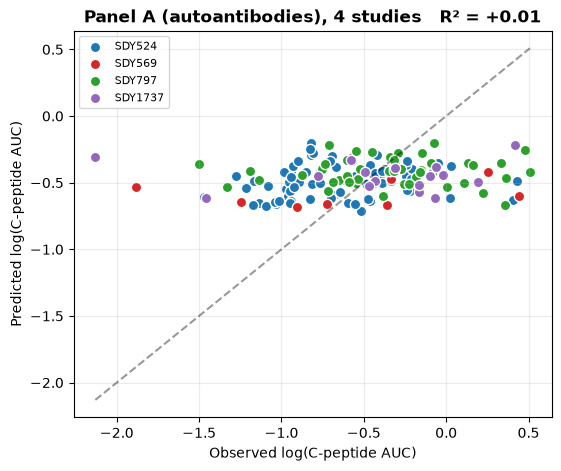

In [5]:
PANEL_A_FEATS = ["MIAA", "GAD65", "IA2IC", "ICA", "ZNT8", "8-12", "13-17", ">18", "Sex"]
PANEL_A_STUDIES = ["SDY524", "SDY569", "SDY797", "SDY1737"]
dataA = {}
for s in PANEL_A_STUDIES:
    a = od.load_panel_a(s)
    dataA[s] = (a[PANEL_A_FEATS].values.astype(float), a[od.PANEL_A_TARGET].values.astype(float))

def fed_cv_panelA(studies):
    folds = {s: list(KFold(min(5, max(2, len(dataA[s][1]) // 2)),
                           shuffle=True, random_state=RNG_SEED).split(dataA[s][0]))
             for s in studies}
    nf = min(len(folds[s]) for s in studies)
    oof = {s: np.full(len(dataA[s][1]), np.nan) for s in studies}
    for k in range(nf):
        coefs, ints, sizes, scalers = [], [], [], {}
        for s in studies:
            X, y = dataA[s]; tr, te = folds[s][k]
            sc = MinMaxScaler().fit(X[tr]); scalers[s] = sc
            m = Ridge(alpha=1.0).fit(sc.transform(X[tr]), y[tr])
            coefs.append(m.coef_); ints.append(m.intercept_); sizes.append(len(tr))
        ac = np.average(np.stack(coefs), axis=0, weights=sizes)
        ai = np.average(np.array(ints), weights=sizes)
        for s in studies:
            X, y = dataA[s]; tr, te = folds[s][k]
            oof[s][te] = scalers[s].transform(X[te]) @ ac + ai
    return oof

oofA = fed_cv_panelA(PANEL_A_STUDIES)
fig, ax = plt.subplots(figsize=(5.5, 4.6), constrained_layout=True)
colA = {"SDY524": "#1f77b4", "SDY569": "#d62728", "SDY797": "#2ca02c", "SDY1737": "#9467bd"}
ally, allp = [], []
for s in PANEL_A_STUDIES:
    y = dataA[s][1]; p = oofA[s]; m = ~np.isnan(p)
    ax.scatter(y[m], p[m], c=colA[s], s=55, edgecolor="white", label=s)
    ally.append(y[m]); allp.append(p[m])
ally = np.concatenate(ally); allp = np.concatenate(allp)
rssA = np.sum((ally - allp) ** 2); tssA = np.sum((ally - ally.mean()) ** 2)
r2A = 1 - rssA / tssA
lo, hi = min(ally.min(), allp.min()), max(ally.max(), allp.max())
ax.plot([lo, hi], [lo, hi], "k--", alpha=0.4)
ax.set_xlabel("Observed log(C-peptide AUC)")
ax.set_ylabel("Predicted log(C-peptide AUC)")
ax.set_title(f"Panel A (autoantibodies), 4 studies   R² = {r2A:+.2f}", fontweight="bold")
ax.legend(fontsize=8); ax.grid(alpha=0.25)
fig.savefig("figures/postlasso_panelA_reference.pdf", dpi=300)
fig.savefig("figures/postlasso_panelA_reference.png", dpi=220)
plt.show()


## 6. Outputs

- `results/postlasso_sdy569_sdy524.csv` — MSE and R² for each method, SDY569
  alone and SDY569 + SDY524.
- `figures/postlasso_scatter_{mlr,lasso,random}.pdf` — per-method scatter.
- `figures/postlasso_panelA_reference.pdf` — Panel A reference.

MLR and LASSO improve when SDY524 is added; Random Forest does not.
